

Dataset already QCed

Runs GRN inference — slowest step, uses all your CPU cores

Prunes with cisTarget — removes weak TF-gene links

Scores every cell with AUCell

Loads AUC scores back into your AnnData

Builds a UMAP from regulon activity and finds top regulons per cluster

```bash

podman pull docker.io/aertslab/pyscenic:0.12.1

# pyenv virtualenv 3.10.14 scenic-env

# pyenv activate scenic-env

# pip install pyscenic jupyter ipykernel

# python -m ipykernel install --user --name scenic-env --display-name "Python (scenic-env)"

```

In [1]:
"""
pySCENIC Minimal Pipeline
=========================

FILES YOU NEED TO PROVIDE:
    - Your own data:
        raw_counts.h5ad          → your scRNA-seq data (AnnData, raw counts, NOT normalized)

FILES TO DOWNLOAD from https://resources.aertslab.org/cistarget/
    - allTFs_hg38.txt            → list of human TF gene names (one per line)
    - *.genes_vs_motifs.rankings.feather  → ranking database (large file, ~1.5 GB)
    - motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl  → motif-to-TF annotation table

    For mouse, replace hg38 → mm10 and hgnc → mgi in the filenames above.
"""

import os
import numpy as np
import pandas as pd
import scanpy as sc
import loompy as lp

In [20]:
# =============================================================================
# 0. FILE PATHS — edit these to match your setup
# =============================================================================

WDIR             = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/SCENIC"  # working directory for intermediate and output files
INPUT_H5AD       = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"            # YOUR raw count data
TF_LIST          = "/home/gdallagl/myworkdir/XDP/utils/SCENIC/allTFs_hg38.txt"            # downloaded TF list
DB_FEATHER       = "/home/gdallagl/myworkdir/XDP/utils/SCENIC/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather"
MOTIF_ANNOT      = "/home/gdallagl/myworkdir/XDP/utils/SCENIC/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl"

# intermediate and output files (auto-generated)
LOOM_SCENIC      = os.path.join(WDIR, "expr_filtered.loom")
ADJACENCIES      = os.path.join(WDIR, "adj.tsv")
REGULONS         = os.path.join(WDIR, "reg.csv")
PYSCENIC_OUTPUT  = os.path.join(WDIR, "pyscenic_output.loom")
ANNDATA_OUT      = os.path.join(WDIR, "anndata_with_auc.h5ad")

NUM_WORKERS = 20   # set to the number of CPU cores available

os.makedirs(WDIR, exist_ok=True)

In [17]:
adata = sc.read_h5ad(INPUT_H5AD, backed="r")
GENE_NAME_COL = "gene_symbol"

In [ ]:
adata = adata[
    (adata.obs["ct_for_deg"] == "Matrix D1") &
    (~adata.obs["ct_for_deg"].str.startswith("-"))
].to_memory().copy()

sc.pp.filter_genes(adata, min_cells=5)
print(f"Genes after basic filter: {adata.n_vars}")

# HVG filtering on normalized data
adata_tmp = adata.copy()
adata_tmp.X = adata_tmp.layers["counts"].copy()
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
sc.pp.log1p(adata_tmp)
sc.pp.highly_variable_genes(adata_tmp, n_top_genes=10000)

# find TFs using gene_symbol column — correct set intersection
tfs = pd.read_csv(TF_LIST, header=None)[0].tolist()
gene_symbols = set(adata.var[GENE_NAME_COL].tolist())
tfs_in_data = list(gene_symbols.intersection(set(tfs)))
print(f"TFs found in data: {len(tfs_in_data)}")

# combine HVGs + TFs
hvg_mask = adata_tmp.var['highly_variable'].copy()
tf_mask  = adata.var[GENE_NAME_COL].isin(tfs_in_data)
hvg_mask = hvg_mask | tf_mask

# subset original adata (raw counts)
adata = adata[:, hvg_mask].copy()
adata.X = adata.layers["counts"]  # make sure X is raw counts for loom
print(f"Genes after HVG + TF filter: {adata.n_vars}")
print(f"TFs retained: {tf_mask.sum()}")

Genes after basic filter: 33098
TFs found in data: 1703


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:629: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_1475116/886273321.py:29: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = adata.layers["counts"]  # make sure X is raw counts for loom


Genes after HVG + TF filter: 11232
TFs retained: 1703


In [ ]:
# =============================================================================
# 1. LOAD DATA WITH SCANPY
#    Input:  raw_counts.h5ad  (your file)
#    Output: expr_filtered.loom
#    IMPORTANT: pySCENIC needs RAW counts. Do not normalize before saving the loom.
# =============================================================================

import scipy.sparse as sp
import scipy.sparse as sp
import h5py

print("Loading counts...")
adata.X = adata.layers["counts"]
X = sp.csr_matrix(adata.X)

nUMI  = np.array(X.sum(axis=1)).flatten()
nGene = np.array((X > 0).sum(axis=1)).flatten()

n_cells, n_genes = X.shape
print(f"Densifying full matrix ({n_cells} cells x {n_genes} genes)...")
dense = X.toarray().T.astype(np.float32)   # genes x cells, all at once
print("Densification done. Writing to disk...")

with h5py.File(LOOM_SCENIC, "w") as f:
    f.attrs["LOOM_SPEC_VERSION"] = "3.0.0"
    f.create_dataset("matrix", data=dense, compression="gzip", compression_opts=1)

    ra = f.create_group("row_attrs")
    ra.create_dataset("Gene", data=np.array(adata.var[GENE_NAME_COL], dtype="S"))

    ca = f.create_group("col_attrs")
    ca.create_dataset("CellID", data=np.array(adata.obs_names, dtype="S"))
    ca.create_dataset("nUMI",   data=nUMI.astype(np.float32))
    ca.create_dataset("nGene",  data=nGene.astype(np.float32))

    f.create_group("row_graphs")
    f.create_group("col_graphs")
    f.create_group("attrs")       # ← this is what was missing


del dense
print(f"Done: {LOOM_SCENIC}")

Loading counts...


/tmp/ipykernel_1475116/2437949375.py:13: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = adata.layers["counts"]


Densifying full matrix (11459 cells x 11232 genes)...
Densification done. Writing to disk...
Done: /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/SCENIC/expr_filtered.loom


In [21]:
# =============================================================================
# 2. GRN INFERENCE  (pyscenic grn)
#    Input:  expr_filtered.loom  +  allTFs_hg38.txt
#    Output: adj.tsv
#
#    This finds co-expression links between TFs and target genes across all cells.
#    --seed makes it reproducible. Slowest step (~30 min to a few hours).
# =============================================================================

print("\n=== Step 2: GRN inference ===")

# mount your home directory — then container paths == real paths, no translation needed
os.system(f"""
podman run --rm \
    -v /home/gdallagl:/home/gdallagl \
    aertslab/pyscenic:0.12.1 \
    pyscenic grn \
        {LOOM_SCENIC} \
        {TF_LIST} \
        --method grnboost2 \
        --output {ADJACENCIES} \
        --num_workers {NUM_WORKERS} \
        --seed 777
""")

print(f"Adjacencies saved: {ADJACENCIES}")


=== Step 2: GRN inference ===


time="2026-03-18T15:24:26Z" level=warning msg="The cgroupv2 manager is set to systemd but there is no systemd user session available"
time="2026-03-18T15:24:26Z" level=warning msg="For using systemd, you may need to login using an user session"
time="2026-03-18T15:24:26Z" level=warning msg="Alternatively, you can enable lingering with: `loginctl enable-linger 1016` (possibly as root)"
time="2026-03-18T15:24:26Z" level=warning msg="Falling back to --cgroup-manager=cgroupfs"



2026-03-18 15:24:36,036 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2026-03-18 15:24:37,867 - pyscenic.cli.pyscenic - INFO - Inferring regulatory networks.

2026-03-18 19:13:18,610 - pyscenic.cli.pyscenic - INFO - Writing results to file.


preparing dask client
parsing input
creating dask graph
20 partitions
computing dask graph
not shutting down client, client was created externally
finished
Adjacencies saved: /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/SCENIC/adj.tsv


In [22]:
# =============================================================================
# 3. CISTARGET PRUNING  (pyscenic ctx)
#    Input:  adj.tsv  +  .feather DB  +  motif annotation table  +  loom
#    Output: reg.csv
#
#    Removes TF-gene links that lack motif evidence in the genome.
#    What survives are called regulons (high-confidence TF → target sets).
# =============================================================================

print("\n=== Step 3: cisTarget pruning ===")

os.system(f"""
podman run --rm \
    -v /home/gdallagl:/home/gdallagl \
    aertslab/pyscenic:0.12.1 \
    pyscenic ctx \
        {ADJACENCIES} \
        {DB_FEATHER} \
        --annotations_fname {MOTIF_ANNOT} \
        --expression_mtx_fname {LOOM_SCENIC} \
        --output {REGULONS} \
        --mask_dropouts \
        --num_workers {NUM_WORKERS}
""")

print(f"Regulons saved: {REGULONS}")


=== Step 3: cisTarget pruning ===


time="2026-03-18T19:18:18Z" level=warning msg="The cgroupv2 manager is set to systemd but there is no systemd user session available"
time="2026-03-18T19:18:18Z" level=warning msg="For using systemd, you may need to login using an user session"
time="2026-03-18T19:18:18Z" level=warning msg="Alternatively, you can enable lingering with: `loginctl enable-linger 1016` (possibly as root)"
time="2026-03-18T19:18:18Z" level=warning msg="Falling back to --cgroup-manager=cgroupfs"

2026-03-18 19:18:32,601 - pyscenic.cli.pyscenic - INFO - Creating modules.

2026-03-18 19:18:34,703 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2026-03-18 19:18:37,432 - pyscenic.utils - INFO - Calculating Pearson correlations.

2026-03-18 19:18:38,330 - pyscenic.utils - WARNING - Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using 

Regulons saved: /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/SCENIC/reg.csv


In [23]:
# =============================================================================
# 4. AUCELL SCORING  (pyscenic aucell)
#    Input:  expr_filtered.loom  +  reg.csv
#    Output: pyscenic_output.loom
#
#    Scores each cell for how active each regulon is.
#    High AUC = that TF's target genes are highly expressed in that cell.
# =============================================================================

print("\n=== Step 4: AUCell scoring ===")

os.system(f"""
podman run --rm \
    -v /home/gdallagl:/home/gdallagl \
    aertslab/pyscenic:0.12.1 \
    pyscenic aucell \
        {LOOM_SCENIC} \
        {REGULONS} \
        --output {PYSCENIC_OUTPUT} \
        --num_workers {NUM_WORKERS}
""")

print(f"AUCell output saved: {PYSCENIC_OUTPUT}")


=== Step 4: AUCell scoring ===


time="2026-03-18T19:30:38Z" level=warning msg="The cgroupv2 manager is set to systemd but there is no systemd user session available"
time="2026-03-18T19:30:38Z" level=warning msg="For using systemd, you may need to login using an user session"
time="2026-03-18T19:30:38Z" level=warning msg="Alternatively, you can enable lingering with: `loginctl enable-linger 1016` (possibly as root)"
time="2026-03-18T19:30:38Z" level=warning msg="Falling back to --cgroup-manager=cgroupfs"

2026-03-18 19:30:52,378 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2026-03-18 19:30:54,457 - pyscenic.cli.pyscenic - INFO - Loading gene signatures.

2026-03-18 19:30:54,709 - pyscenic.cli.pyscenic - INFO - Calculating cellular enrichment.


Create regulons from a dataframe of enriched features.
Additional columns saved: []



2026-03-18 19:31:23,957 - pyscenic.cli.pyscenic - INFO - Writing results to file.
/opt/venv/lib/python3.10/site-packages/pyscenic/cli/utils.py:347: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for name, threshold in auc_thresholds.iteritems()
Traceback (most recent call last):
  File "/opt/venv/bin/pyscenic", line 33, in <module>
    sys.exit(load_entry_point('pyscenic==0.12.1+0.gce41b61.dirty', 'console_scripts', 'pyscenic')())
  File "/opt/venv/lib/python3.10/site-packages/pyscenic/cli/pyscenic.py", line 713, in main
    args.func(args)
  File "/opt/venv/lib/python3.10/site-packages/pyscenic/cli/pyscenic.py", line 296, in aucell_command
    append_auc_mtx(
  File "/opt/venv/lib/python3.10/site-packages/pyscenic/cli/utils.py", line 388, in append_auc_mtx
    ds.attrs[ATTRIBUTE_NAME_METADATA] = compress_meta(meta_data)
  File "/opt/venv/lib/python3.10/site-packages/loompy/global_attribute_manager.py", line 66, in __setitem__
   

AUCell output saved: /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/SCENIC/pyscenic_output.loom


In [ ]:
# =============================================================================
# 5. LOAD AUC SCORES BACK INTO SCANPY
#    Input:  pyscenic_output.loom
#    Output: AUC scores added to adata
# =============================================================================

print("\n=== Step 5: Load AUC scores into AnnData ===")

lf = lp.connect(PYSCENIC_OUTPUT, mode='r', validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

adata = sc.read_h5ad(ANNDATA_OUT)
auc_mtx = auc_mtx.loc[adata.obs_names]   # align cell order

adata.obsm['X_scenic']       = auc_mtx.values
adata.uns['scenic_regulons'] = list(auc_mtx.columns)

# Also store each regulon as a column in obs for easy sc.pl.umap plotting
for col in auc_mtx.columns:
    adata.obs[col] = auc_mtx[col].values

# DOWNSTREAM ANALYSIS

Loading AUC matrix from pySCENIC output...
AUC matrix: 11459 cells x 34 regulons
Common cells: 11459


/tmp/ipykernel_1475116/1793736936.py:22: ImplicitModificationWarning: Setting element `.obsm['X_scenic']` of view, initializing view as actual.
  adata.obsm['X_scenic'] = auc_mtx.values



=== Step 6: Downstream analysis ===


/tmp/ipykernel_1475116/1793736936.py:38: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_auc, key_added='scenic_clusters', resolution=0.5)


KeyError: 'Could not find key leiden in .var_names or .obs.columns.'

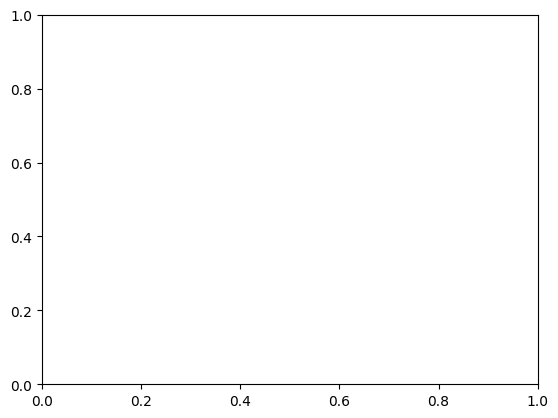

In [ ]:
import loompy
import pandas as pd
import scanpy as sc

# =============================================================================
# LOAD RESULTS — start here if GRN/ctx/aucell already finished
# =============================================================================

print("Loading AUC matrix from pySCENIC output...")
lf = loompy.connect(PYSCENIC_OUTPUT, mode='r', validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()
print(f"AUC matrix: {auc_mtx.shape[0]} cells x {auc_mtx.shape[1]} regulons")

# align cell order between AUC matrix and adata
common_cells = adata.obs_names.intersection(auc_mtx.index)
adata   = adata[common_cells]
auc_mtx = auc_mtx.loc[common_cells]
print(f"Common cells: {len(common_cells)}")

# store AUC scores in adata
adata.obsm['X_scenic'] = auc_mtx.values
for col in auc_mtx.columns:
    adata.obs[col] = auc_mtx[col].values

# =============================================================================
# DOWNSTREAM ANALYSIS
# =============================================================================

print("\n=== Step 6: Downstream analysis ===")

# --- 6a. UMAP based on regulon activity ---
adata_auc = sc.AnnData(X=auc_mtx.values, obs=adata.obs)
adata_auc.var_names = auc_mtx.columns

sc.pp.neighbors(adata_auc, use_rep='X', n_neighbors=15, metric='correlation')
sc.tl.umap(adata_auc)
sc.tl.leiden(adata_auc, key_added='scenic_clusters', resolution=0.5)

adata.obsm['X_umap_scenic'] = adata_auc.obsm['X_umap']
adata.obs['scenic_clusters'] = adata_auc.obs['scenic_clusters']


In [27]:
adata

AnnData object with n_obs × n_vars = 11459 × 11232
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_ons

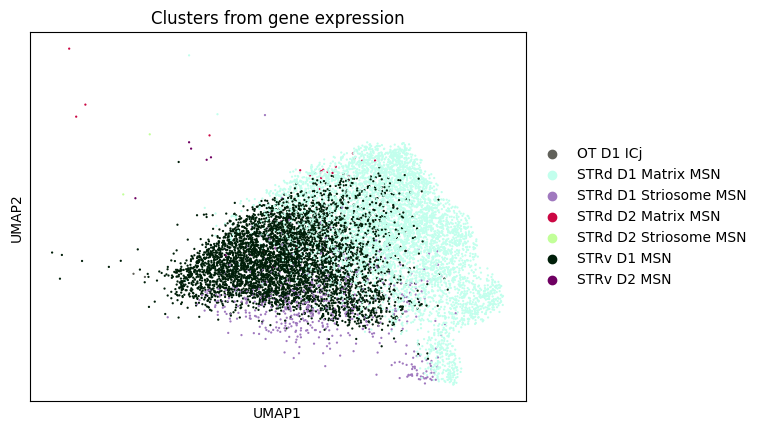

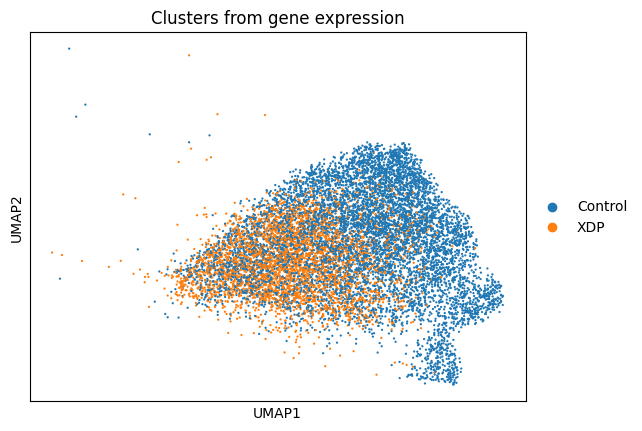

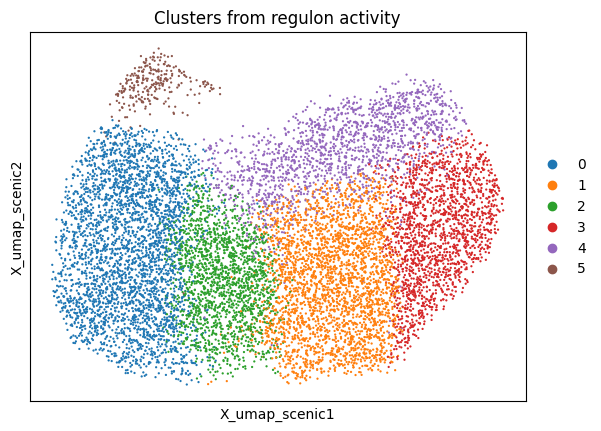

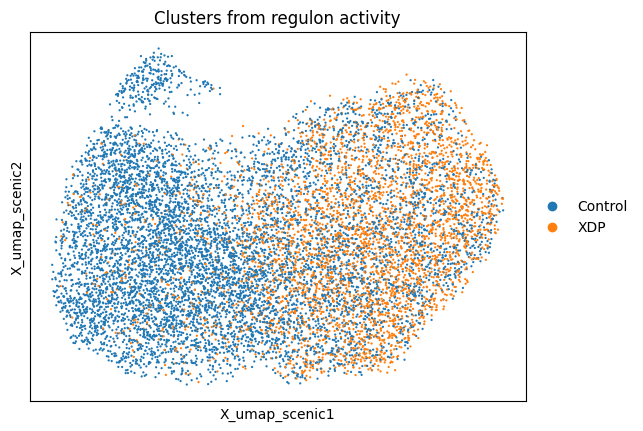


Top 3 regulons per cluster:
  Cluster Control: ['THRB(+)', 'RFX3(+)', 'RARB(+)', 'MITF(+)', 'TCF12(+)', 'RXRG(+)', 'BACH2(+)', 'ETV5(+)', 'SMAD3(+)', 'ZNF148(+)']
  Cluster XDP: ['RFX3(+)', 'THRB(+)', 'TCF12(+)', 'RARB(+)', 'MITF(+)', 'RXRG(+)', 'BACH2(+)', 'ETS2(+)', 'ETV5(+)', 'HLTF(+)']


/tmp/ipykernel_1475116/3967591422.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct)


In [35]:
# --- 6b. Plot Scanpy vs SCENIC UMAP ---
sc.pl.embedding(adata, basis='umap',          color='Group_name',
                title='Clusters from gene expression')
sc.pl.embedding(adata, basis='umap',          color='condition',
                title='Clusters from gene expression')
sc.pl.embedding(adata, basis='X_umap_scenic', color='scenic_clusters',
                title='Clusters from regulon activity')
sc.pl.embedding(adata, basis='X_umap_scenic', color='condition',
                title='Clusters from regulon activity')

# --- 6c. Top active regulons per cluster ---
ct = "condition"
cluster_mean_auc = (
    auc_mtx
    .join(adata.obs[[ct]])
    .groupby(ct)
    .mean()
)

print("\nTop 3 regulons per cluster:")
for cluster in cluster_mean_auc.index:
    top3 = cluster_mean_auc.loc[cluster].nlargest(10).index.tolist()
    print(f"  Cluster {cluster}: {top3}")

In [41]:
from scipy.stats import mannwhitneyu
import pandas as pd

# aggregate to donor level
pseudobulk = (
    auc_mtx
    .join(adata.obs[['condition', 'donor_id']])
    .groupby(['donor_id', 'condition'], observed=True)
    .mean()
    .reset_index()   # this brings condition back as a column
)

print(pseudobulk.shape)
print(pseudobulk['condition'].value_counts())  # verify counts

results = []
for regulon in auc_mtx.columns:
    ctrl = pseudobulk.loc[pseudobulk['condition'] == 'Control', regulon].values
    xdp  = pseudobulk.loc[pseudobulk['condition'] == 'XDP',     regulon].values
    
    print(f"{regulon}: ctrl n={len(ctrl)}, xdp n={len(xdp)}")  # debug
    
    stat, pval = mannwhitneyu(ctrl, xdp, alternative='two-sided')
    fc = xdp.mean() / (ctrl.mean() + 1e-10)
    results.append({'regulon': regulon, 'pval': pval, 'fold_change': fc})

df = pd.DataFrame(results).sort_values('pval')
display(df.head(20))

from statsmodels.stats.multitest import multipletests

df['pval_adj'] = multipletests(df['pval'], method='fdr_bh')[1]
print(df[df['pval_adj'] < 0.05].sort_values('pval_adj'))

(47, 36)
condition
XDP        30
Control    17
Name: count, dtype: int64
AHDC1(+): ctrl n=17, xdp n=30
ATF3(+): ctrl n=17, xdp n=30
BACH2(+): ctrl n=17, xdp n=30
BCL6(+): ctrl n=17, xdp n=30
BCLAF1(+): ctrl n=17, xdp n=30
CUX1(+): ctrl n=17, xdp n=30
ETS2(+): ctrl n=17, xdp n=30
ETV5(+): ctrl n=17, xdp n=30
FOS(+): ctrl n=17, xdp n=30
FOSB(+): ctrl n=17, xdp n=30
FOSL2(+): ctrl n=17, xdp n=30
FOXO3(+): ctrl n=17, xdp n=30
HLTF(+): ctrl n=17, xdp n=30
HMGA1(+): ctrl n=17, xdp n=30
JUNB(+): ctrl n=17, xdp n=30
JUND(+): ctrl n=17, xdp n=30
KLF12(+): ctrl n=17, xdp n=30
KLF4(+): ctrl n=17, xdp n=30
MITF(+): ctrl n=17, xdp n=30
NFE2L1(+): ctrl n=17, xdp n=30
NFIL3(+): ctrl n=17, xdp n=30
NR2F1(+): ctrl n=17, xdp n=30
OTUD4(+): ctrl n=17, xdp n=30
PGR(+): ctrl n=17, xdp n=30
PURA(+): ctrl n=17, xdp n=30
RARB(+): ctrl n=17, xdp n=30
RFX3(+): ctrl n=17, xdp n=30
RXRG(+): ctrl n=17, xdp n=30
SMAD3(+): ctrl n=17, xdp n=30
TCF12(+): ctrl n=17, xdp n=30
THRB(+): ctrl n=17, xdp n=30
ZBTB11(+): ctrl

,regulon,pval,fold_change
25,RARB(+),0.000001,0.749563
28,SMAD3(+),0.000009,0.539849
18,MITF(+),0.000010,0.809914
16,KLF12(+),0.000025,1.653563
26,RFX3(+),0.000030,1.205590
6,ETS2(+),0.000044,1.676336
27,RXRG(+),0.000102,0.792322
30,THRB(+),0.003861,0.899886
21,NR2F1(+),0.009899,3.039531
29,TCF12(+),0.013562,1.075565


     regulon      pval  fold_change  pval_adj
25   RARB(+)  0.000001     0.749563  0.000040
28  SMAD3(+)  0.000009     0.539849  0.000113
18   MITF(+)  0.000010     0.809914  0.000113
16  KLF12(+)  0.000025     1.653563  0.000204
26   RFX3(+)  0.000030     1.205590  0.000204
6    ETS2(+)  0.000044     1.676336  0.000250
27   RXRG(+)  0.000102     0.792322  0.000496
30   THRB(+)  0.003861     0.899886  0.016408
21  NR2F1(+)  0.009899     3.039531  0.037395
29  TCF12(+)  0.013562     1.075565  0.046112


KeyError: 'Could not find key TF_name(+) in .var_names or .obs.columns.'

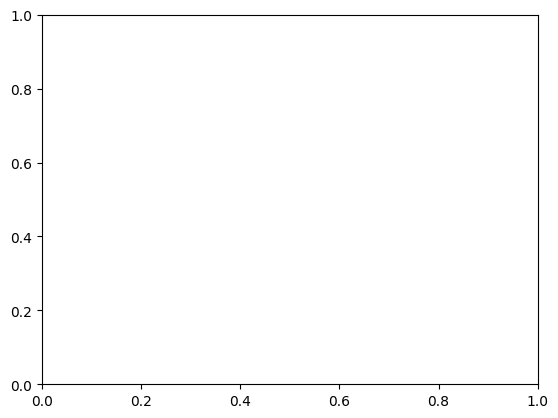

In [44]:
# In scanpy/AnnData workflow
sc.tl.rank_genes_groups(adata_auc, groupby='condition',  # 'healthy' vs 'disease'
                         layer=None)  # use your AUC matrix

# UMAP colored by regulon AUC
sc.pl.umap(adata_auc, color=['TF_name(+)'])  # SCENIC appends (+) to regulon names

# Heatmap across cell types & conditions
sc.pl.matrixplot(adata_auc, var_names=top_regulons, 
                 groupby=['cell_type', 'condition'])

In [45]:
# See all regulon names in your AUC adata
print(adata_auc.var_names.tolist())

# Or just the first 20
print(adata_auc.var_names[:20].tolist())

['AHDC1(+)', 'ATF3(+)', 'BACH2(+)', 'BCL6(+)', 'BCLAF1(+)', 'CUX1(+)', 'ETS2(+)', 'ETV5(+)', 'FOS(+)', 'FOSB(+)', 'FOSL2(+)', 'FOXO3(+)', 'HLTF(+)', 'HMGA1(+)', 'JUNB(+)', 'JUND(+)', 'KLF12(+)', 'KLF4(+)', 'MITF(+)', 'NFE2L1(+)', 'NFIL3(+)', 'NR2F1(+)', 'OTUD4(+)', 'PGR(+)', 'PURA(+)', 'RARB(+)', 'RFX3(+)', 'RXRG(+)', 'SMAD3(+)', 'TCF12(+)', 'THRB(+)', 'ZBTB11(+)', 'ZNF148(+)', 'ZNF548(+)']
['AHDC1(+)', 'ATF3(+)', 'BACH2(+)', 'BCL6(+)', 'BCLAF1(+)', 'CUX1(+)', 'ETS2(+)', 'ETV5(+)', 'FOS(+)', 'FOSB(+)', 'FOSL2(+)', 'FOXO3(+)', 'HLTF(+)', 'HMGA1(+)', 'JUNB(+)', 'JUND(+)', 'KLF12(+)', 'KLF4(+)', 'MITF(+)', 'NFE2L1(+)']
